In [6]:
import pandas as pd 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00264/EEG%20Eye%20State.arff"
df = pd.read_csv(url, comment = '@', header = None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [7]:
df.columns = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4", "eye_state"] 

In [8]:
df["eye_state"].value_counts()

eye_state
0    8257
1    6723
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split 
x = df[["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]]
y = df["eye_state"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 100)

from sklearn.neighbors import KNeighborsClassifier 
model = KNeighborsClassifier(n_neighbors = 10)
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(accuracy)

0.9562750333778371


In [10]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
x = df[["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]]
y = df["eye_state"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 200)

model1 = RandomForestClassifier(n_estimators = 100)
model1.fit(x_train, y_train)
accuracy = model1.score(x_test, y_test)
print(accuracy)

0.9302403204272364


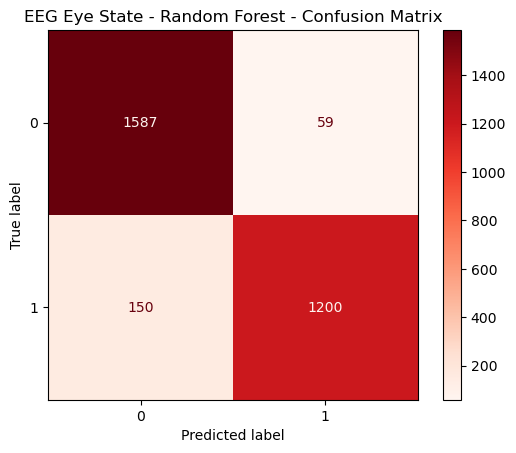

In [11]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay 
import matplotlib.pyplot as plt 
y_pred = model1.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix = cm)
display.plot(cmap = 'Reds')
plt.title("EEG Eye State - Random Forest - Confusion Matrix")
plt.show()

In [12]:
df["eye_state"].value_counts()

eye_state
0    8257
1    6723
Name: count, dtype: int64

In [13]:
importances = model1.feature_importances_ 
features = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
importance_df = pd.DataFrame({"electrode": features, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending = False)
print(importance_df) 

   electrode  importance
6         O1    0.116514
5         P7    0.107378
1         F7    0.092068
12        F8    0.082560
13       AF4    0.076544
0        AF3    0.076395
10       FC6    0.060980
11        F4    0.060392
3        FC5    0.059247
7         O2    0.058494
9         T8    0.055469
4         T7    0.055179
2         F3    0.052797
8         P8    0.045984


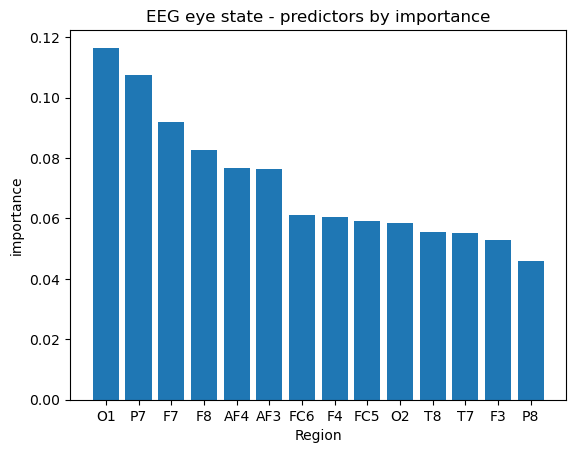

In [14]:
plt.bar(importance_df["electrode"], importance_df["importance"])
plt.xlabel("Region")
plt.ylabel("importance")
plt.title("EEG eye state - predictors by importance")
plt.show()

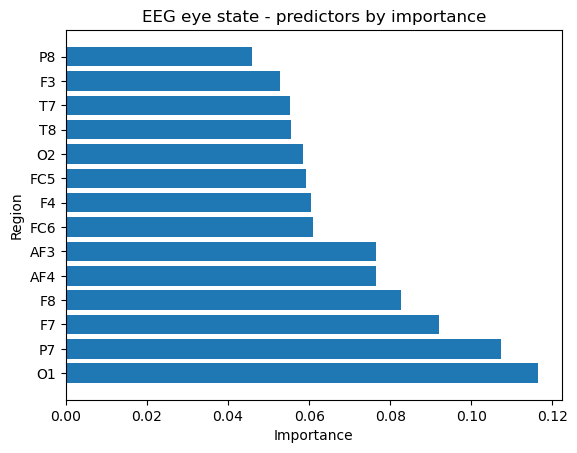

In [15]:
plt.barh(importance_df["electrode"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Region")
plt.title("EEG eye state - predictors by importance")
plt.show()

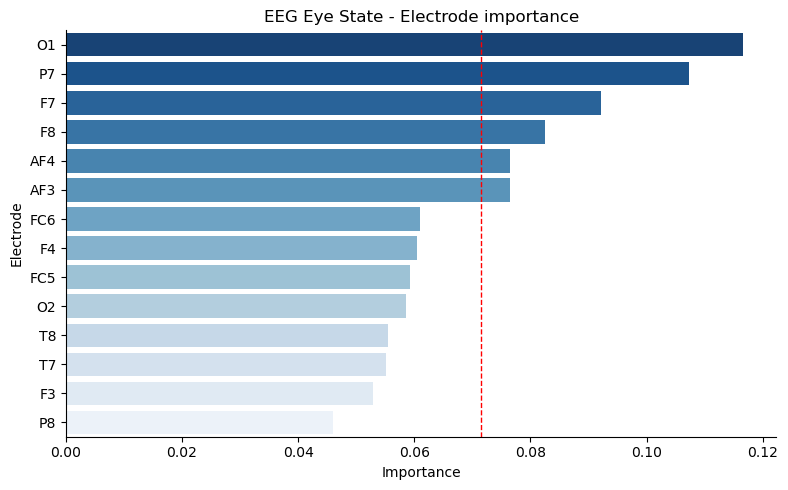

In [16]:
import seaborn as sns

plt.figure(figsize = (8, 5))
sns.barplot(data = importance_df, x = "importance", y = "electrode", hue = "electrode", palette = "Blues_r", legend = False)
plt.title("EEG Eye State - Electrode importance")
plt.xlabel("Importance")
plt.ylabel("Electrode")
plt.tight_layout()
plt.axvline(x = importance_df["importance"].mean(), color = 'red', linestyle = '--', linewidth = 1, label = 'Mean')
sns.despine()
plt.show()

In [17]:
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [18]:
O1_open = df[df["eye_state"]==1]["O1"]
O1_closed = df[df["eye_state"]==0]["O1"]

from scipy import stats
t, p = stats.ttest_ind(O1_open, O1_closed)
print(f"t = {t:.3f}, p = {p:.4f}")

t = -0.884, p = 0.3767


In [19]:
print("Eyes open - Mean:" , O1_open.mean(), "Eyes open - std:", O1_open.std())
print("Eyes closed - Mean:" , O1_closed.mean(), "Eyes closed - std:", O1_closed.std())

Eyes open - Mean: 4073.570684218355 Eyes open - std: 34.21363193195217
Eyes closed - Mean: 4140.387390093254 Eyes closed - std: 6197.0521171870705


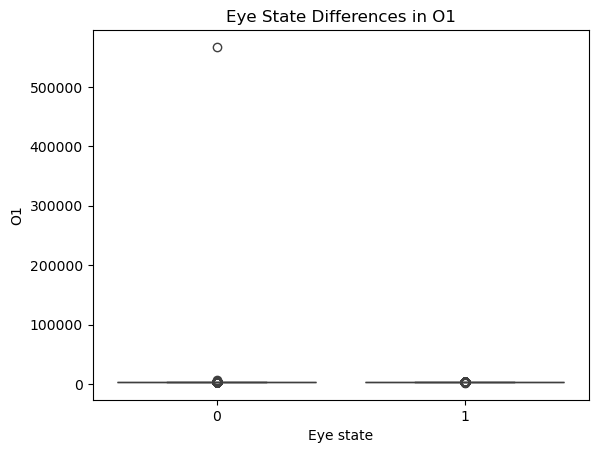

In [20]:
# Explains why the t-test missed it, t-tests compare means, and the means are close. But the distributions are very different.
# I'm gonna make a boxplot just to visualize things better

sns.boxplot(data = df, x = "eye_state", y = "O1")
plt.title("Eye State Differences in O1")
plt.xlabel("Eye state")
plt.ylabel("O1")
plt.show()

In [21]:
df[df["O1"] > 100000]

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
10386,7398.46,2830.77,2457.44,642564.0,6474.36,8092.31,567179.0,5087.69,7143.59,1816.41,6137.95,6904.62,3504.1,121026.0,0


In [22]:
df_clean = df.copy()

In [23]:
df_clean = df_clean.drop(10386)

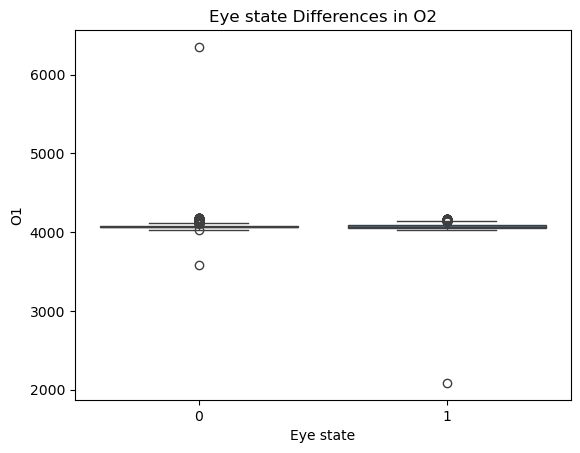

In [24]:
sns.boxplot(data = df_clean, x = "eye_state", y = "O1")
plt.title("Eye state Differences in O2")
plt.xlabel("Eye state")
plt.ylabel("O1")
plt.show()

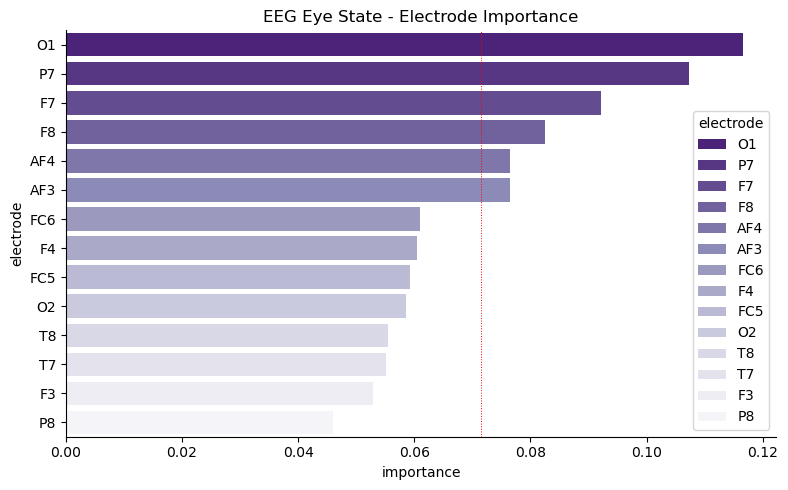

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (8, 5))
sns.barplot(data = importance_df, x = "importance", y = "electrode", hue = "electrode", palette = "Purples_r", legend = True)
plt.title("EEG Eye State - Electrode Importance")
plt.tight_layout()

plt.axvline(x = importance_df["importance"].mean(), color= 'red', linestyle = ':', linewidth = 0.7, label = "Mean")
sns.despine()
plt.show()

In [31]:
%who

ConfusionMatrixDisplay	 KNeighborsClassifier	 O1_closed	 O1_open	 RandomForestClassifier	 accuracy	 cm	 confusion_matrix	 dataframe_columns	 
dataframe_hash	 df	 df_clean	 display	 dtypes_str	 features	 get_dataframes	 getpass	 hashlib	 
import_pandas_safely	 importance_df	 importances	 is_data_frame	 json	 model	 model1	 p	 pd	 
plt	 sns	 stats	 t	 train_test_split	 url	 x	 x_test	 x_train	 
y	 y_pred	 y_test	 y_train	 


In [35]:
x

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77


In [37]:
x.corr()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
AF3,1.000000,0.261146,0.474569,0.012173,0.278938,0.007958,0.006630,0.040539,0.999607,-0.070801,0.572997,-0.394334,0.998714,0.012070
F7,0.261146,1.000000,0.583317,-0.208922,-0.250816,-0.042288,-0.210591,0.517816,0.264922,0.489010,0.317418,0.275977,0.251327,-0.071895
F3,0.474569,0.583317,1.000000,-0.330162,-0.272186,-0.596566,-0.335514,0.221270,0.486506,0.191273,0.517950,0.116761,0.500276,-0.637363
FC5,0.012173,-0.208922,-0.330162,1.000000,0.504616,0.009049,0.999961,0.130482,0.013228,-0.519498,0.420311,0.515388,-0.005351,0.161155
T7,0.278938,-0.250816,-0.272186,0.504616,1.000000,0.409277,0.504231,-0.030063,0.264913,-0.225508,0.336173,-0.095902,0.267107,0.478852
P7,0.007958,-0.042288,-0.596566,0.009049,0.409277,1.000000,0.013707,0.208167,-0.012528,0.420539,-0.196873,-0.229149,-0.030921,0.988310
O1,0.006630,-0.210591,-0.335514,0.999961,0.504231,0.013707,1.000000,0.133434,0.007638,-0.515699,0.417041,0.517621,-0.011080,0.165730
O2,0.040539,0.517816,0.221270,0.130482,-0.030063,0.208167,0.133434,1.000000,0.047843,0.640387,0.433333,0.577013,0.020493,0.224627
P8,0.999607,0.264922,0.486506,0.013228,0.264913,-0.012528,0.007638,0.047843,1.000000,-0.074047,0.577472,-0.385643,0.998849,-0.008055
T8,-0.070801,0.489010,0.191273,-0.519498,-0.225508,0.420539,-0.515699,0.640387,-0.074047,1.000000,0.038252,0.132692,-0.082256,0.336282


In [39]:
df[["FC5", "O1"]].head()

,FC5,O1
0,4148.21,4096.92
1,4148.72,4097.44
2,4156.41,4096.92
3,4155.90,4097.44
4,4151.28,4095.90


In [41]:
x.std()

AF3    2492.072174
F7       45.941672
F3       44.428052
FC5    5216.404632
T7       34.738821
P7     2924.789537
O1     4600.926543
O2       29.292603
P8     2136.408523
T8       38.050903
FC6      37.785981
F4       41.544312
F8     1208.369958
AF4    5891.285043
dtype: float64

In [45]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x) 
print(x_scaled)

[[ 0.00293429 -0.01170422  0.56739848 ...  0.03074472  0.01712667
  -0.0038339 ]
 [ 0.00108436 -0.1120522   0.6713903  ...  0.0061918   0.0145777
  -0.00548894]
 [ 0.00231631 -0.06742891  0.70582915 ...  0.06781481  0.01118458
  -0.00461813]
 ...
 [-0.0178483  -0.41353148 -0.39058683 ... -0.51230804 -0.01937827
  -0.01306139]
 [-0.01496707 -0.39132867 -0.28682009 ... -0.29012821 -0.01555481
  -0.01114664]
 [-0.01373512 -0.26834254 -0.09054115 ... -0.11729493 -0.01428032
  -0.01114664]]


In [48]:
type(x_scaled)

numpy.ndarray

In [61]:
from sklearn.decomposition import PCA 

pca = PCA(n_components = 4)
pca.fit(x_scaled)

,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [62]:
pca.fit(x_scaled)

,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [63]:
print(pca.explained_variance_ratio_)

[0.29246241 0.23902097 0.19585452 0.18783663]


In [64]:
2.92462410e-01 + 2.39020975e-01 + 1.95854518e-01 + 1.87836627e-01

0.91517453

In [65]:
3.54110757e-02+ 2.76470431e-02 +1.29460290e-02+ 4.66961436e-03 + 2.95729368e-03 + 1.18049683e-03 + 1.06556448e-05 + 2.41579794e-06 + 4.69046511e-07 + 3.77624444e-07

0.08482547078369503

In [66]:
x_pca = pca.fit_transform(x_scaled)
print(x_pca)

[[ 0.4178073  -0.01306569  0.28856727  0.56742933]
 [ 0.36421576 -0.07654914  0.32675033  0.31571214]
 [ 0.32721677 -0.13621913  0.35019806  0.12514342]
 ...
 [-0.63609974 -0.11004379 -0.49994068 -0.53992691]
 [-0.52682472 -0.10969886 -0.32483284 -0.26590071]
 [-0.37329985 -0.19290387 -0.11959876  0.09332011]]


In [68]:
x_pca.shape

(14980, 4)

In [70]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
KNeighborsClassifier     ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
O1_closed                Series                    Shape: (8257,)
O1_open                  Series                    Shape: (6723,)
PCA                      ABCMeta                   <class 'sklearn.decomposition._pca.PCA'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
accuracy                 float                     0.9302403204272364
cm                       ndarray                   2x2: 4 elems, type `int64`, 32 bytes
confusion_matrix         function                  <function confusi

In [74]:
from sklearn.model_selection import train_test_split 
x2_train , x2_test, y2_train, y2_test = train_test_split(x_pca, y, test_size=0.2, random_state=50)

In [75]:
model2 = KNeighborsClassifier(n_neighbors = 1) 
model2.fit(x2_train, y2_train) 
accuracy = model2.score(x2_test, y2_test) 
print(accuracy)

0.6288384512683578


In [77]:
from sklearn.ensemble import RandomForestClassifier 

model3 = RandomForestClassifier(n_estimators = 100)
model3.fit(x2_train, y2_train)
accuracy3 = model3.score(x2_test, y2_test)
print(accuracy3)

0.6725634178905207
